# Uber Ride Fare Prediction — EDA & PCA

Goal: explore the Uber fares dataset, engineer simple features, and compare regression models **with** and **without** PCA using R², RMSE, and MAE.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")
pd.set_option("display.width", 120)

## 1. Load data

In [2]:
df = pd.read_csv("dataset/uber.csv")
print(df.shape)
df.head()

(200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
df.info()
print("show empty columns")
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB
show empty columns


Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

## 2. Clean data

Drop unusable rows: missing coordinates, non-positive fares, impossible passenger counts, and GPS coordinates outside the NYC area (this dataset is NYC taxi/Uber trips).

In [4]:
df = df.drop(columns=["Unnamed: 0", "key"], errors="ignore").dropna()

df = df[
    (df.fare_amount > 0) & (df.fare_amount < 200) &
    (df.passenger_count.between(1, 6)) &
    (df.pickup_longitude.between(-75, -72)) & (df.dropoff_longitude.between(-75, -72)) &
    (df.pickup_latitude.between(40, 42)) & (df.dropoff_latitude.between(40, 42))
].copy()

print(df.shape)

(195095, 7)


## 3. Feature engineering

Turn raw coordinates and timestamps into features a model can use: trip distance (haversine) and time-of-day/week/year components.

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(df.pickup_latitude, df.pickup_longitude, df.dropoff_latitude, df.dropoff_longitude)
df = df[(df.distance_km > 0) & (df.distance_km < 100)]

df["pickup_datetime"] = pd.to_datetime(df.pickup_datetime)
df["hour"] = df.pickup_datetime.dt.hour
df["day_of_week"] = df.pickup_datetime.dt.dayofweek
df["month"] = df.pickup_datetime.dt.month
df["year"] = df.pickup_datetime.dt.year

df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hour,day_of_week,month,year
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,19,3,5,2015
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,20,4,7,2009
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,21,0,8,2009
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,8,4,6,2009
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,17,3,8,2014


## 4. EDA

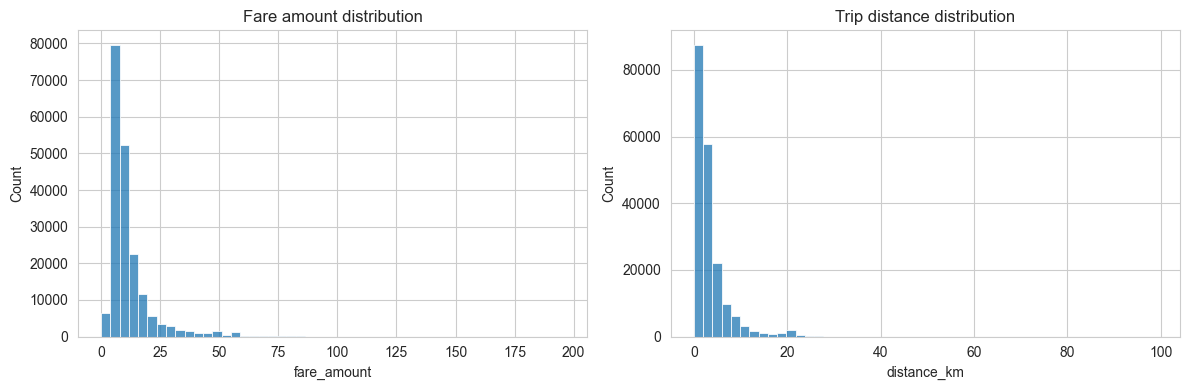

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.fare_amount, bins=50, ax=axes[0]).set_title("Fare amount distribution")
sns.histplot(df.distance_km, bins=50, ax=axes[1]).set_title("Trip distance distribution")
plt.tight_layout()

Text(0.5, 1.0, 'Fare vs distance (sample)')

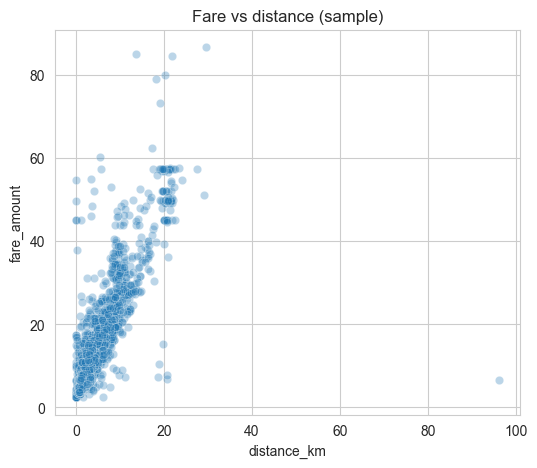

In [7]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x="distance_km", y="fare_amount", alpha=0.3)
plt.title("Fare vs distance (sample)")

Text(0.5, 1.0, 'Average fare by hour')

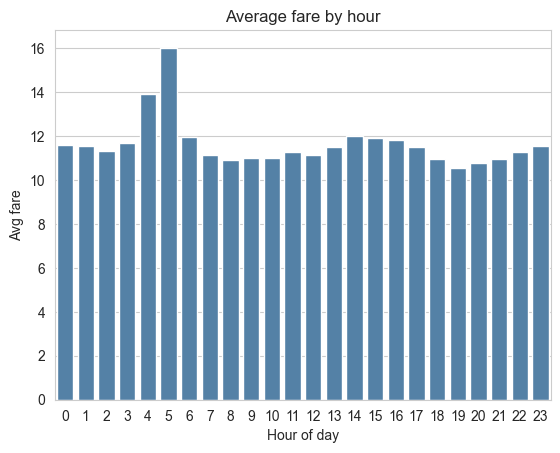

In [8]:
sns.barplot(x=df.groupby("hour").fare_amount.mean().index, y=df.groupby("hour").fare_amount.mean().values, color="steelblue")
plt.xlabel("Hour of day"); plt.ylabel("Avg fare"); plt.title("Average fare by hour")

Text(0.5, 1.0, 'Correlation matrix')

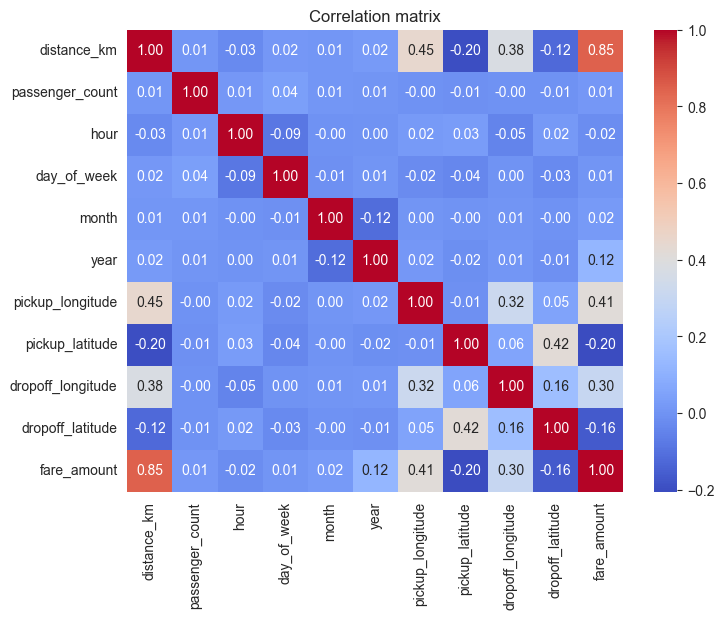

In [9]:
features = ["distance_km", "passenger_count", "hour", "day_of_week", "month", "year",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[features + ["fare_amount"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")

`distance_km` is clearly the strongest predictor; the rest add weaker, partly redundant signal — a good candidate for PCA.

## 5. Train/test split & scaling

In [10]:
X = df[features]
y = df["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 6. PCA

Reduce the 10 scaled features down to the components that explain 95% of the variance.

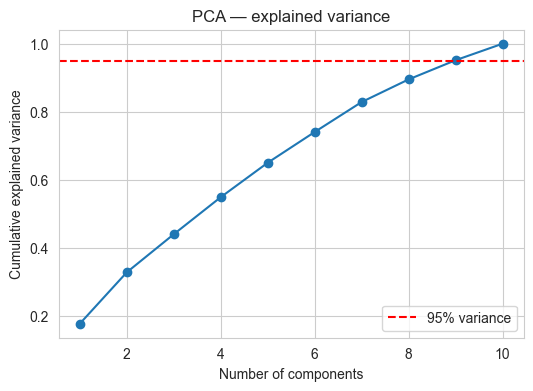

In [11]:
pca_full = PCA().fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance")
plt.title("PCA — explained variance"); plt.legend()

In [12]:
n_components = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_components} (out of {X_train.shape[1]})")

pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

Components needed for 95% variance: 9 (out of 10)


## 7. Models: with vs. without PCA

In [13]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        "R2": r2_score(y_te, preds),
        "RMSE": mean_squared_error(y_te, preds) ** 0.5,
        "MAE": mean_absolute_error(y_te, preds),
    }

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    row_no_pca = evaluate(model, X_train_s, X_test_s, y_train, y_test)
    row_pca = evaluate(model, X_train_pca, X_test_pca, y_train, y_test)
    results.append({"Model": name, "PCA": "No", **row_no_pca})
    results.append({"Model": name, "PCA": f"Yes ({n_components} comps)", **row_pca})

results_df = pd.DataFrame(results)
results_df

,Model,PCA,R2,RMSE,MAE
0,Linear Regression,No,0.701958,5.235709,2.294109
1,Linear Regression,Yes (9 comps),0.555325,6.395252,3.482643
2,Random Forest,No,0.862653,3.554233,1.826503
3,Random Forest,Yes (9 comps),0.821774,4.048758,2.164409


## 8. Compare results

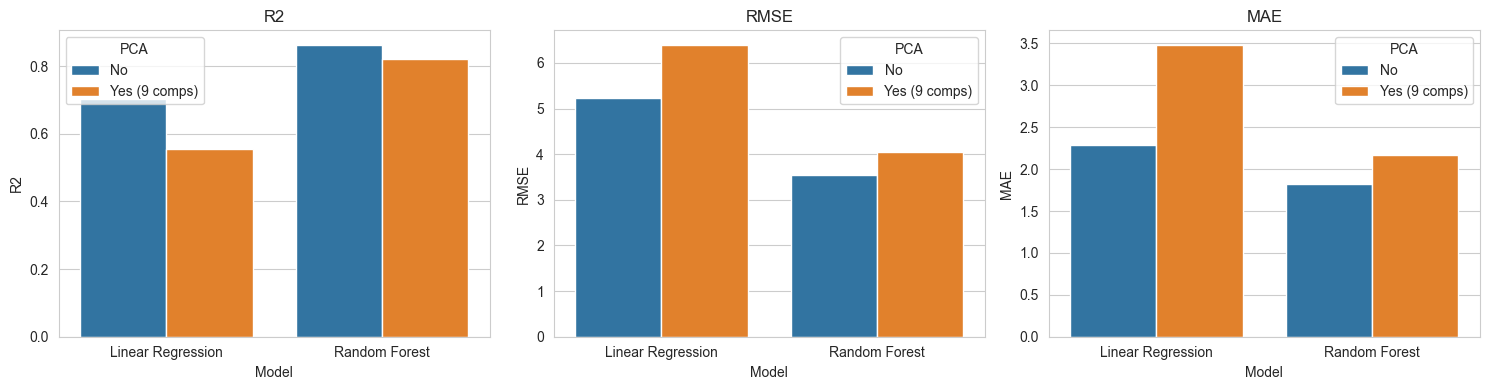

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    sns.barplot(data=results_df, x="Model", y=metric, hue="PCA", ax=ax)
    ax.set_title(metric)
plt.tight_layout()

## Conclusion

- `distance_km` dominates fare prediction; the other engineered features add modest signal.
- PCA compresses the 10 features into far fewer components while retaining 95% of variance, at a small cost in accuracy (R²/RMSE/MAE) — a reasonable tradeoff when dimensionality or training cost matters, but not necessary here since the feature count is already small.
- Random Forest outperforms Linear Regression in both settings since fare vs. distance/time relationships are non-linear.